In [1]:
import joblib

# Load test split and trained artifacts
X_test, y_test = joblib.load('../data/test.joblib')
iso = joblib.load('../backend/models/isolation_forest.joblib')
lr = joblib.load('../backend/models/logistic_regression.joblib')
rf = joblib.load('../backend/models/random_forest.joblib')
thresholds = joblib.load('../backend/models/thresholds.joblib')

best_threshold_lr = thresholds['lr']
best_threshold_rf = thresholds['rf']

# Model outputs used by evaluation cells
iso_preds = (iso.predict(X_test) == -1).astype(int)
lr_probs = lr.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

print(f'Loaded test rows: {X_test.shape[0]}')
print(f'Fraud in test set: {int(y_test.sum())}')
print(f'LR threshold: {best_threshold_lr:.6f}')
print(f'RF threshold: {best_threshold_rf:.6f}')

Loaded test rows: 56962
Fraud in test set: 98
LR threshold: 0.890000
RF threshold: 0.800000


In [2]:
from sklearn.metrics import classification_report

required = ['iso_preds', 'lr_probs', 'rf_probs', 'best_threshold_lr', 'best_threshold_rf', 'y_test']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run Cell 1 first. Missing variables: {missing}")

models = {
    'Isolation Forest': globals()['iso_preds'],
    'Logistic Regression': (globals()['lr_probs'] >= globals()['best_threshold_lr']).astype(int),
    'Random Forest': (globals()['rf_probs'] >= globals()['best_threshold_rf']).astype(int),
}

y_true = globals()['y_test']

for name, preds in models.items():
    print(f"\n{'=' * 40}")
    print(f"  {name}")
    print('=' * 40)
    print(classification_report(y_true, preds, target_names=['Legit', 'Fraud']))


  Isolation Forest
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.24      0.31      0.27        98

    accuracy                           1.00     56962
   macro avg       0.62      0.65      0.63     56962
weighted avg       1.00      1.00      1.00     56962


  Logistic Regression
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00     56864
       Fraud       0.19      0.89      0.31        98

    accuracy                           0.99     56962
   macro avg       0.59      0.94      0.65     56962
weighted avg       1.00      0.99      1.00     56962


  Random Forest
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.95      0.76      0.84        98

    accuracy                           1.00     56962
   macro avg       0.97      0.88      0.92     56962
weighted avg  

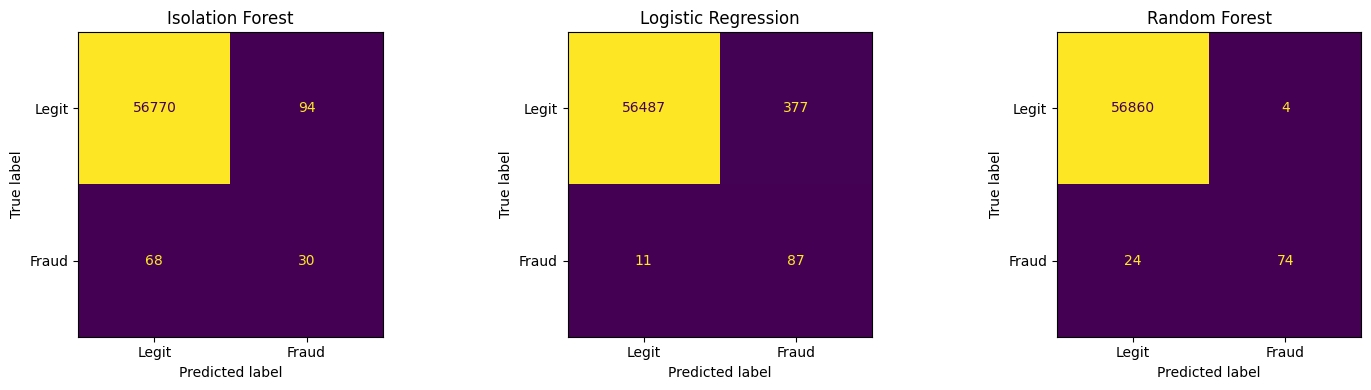

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig('../assets/confusion_matrices.png', dpi=150)

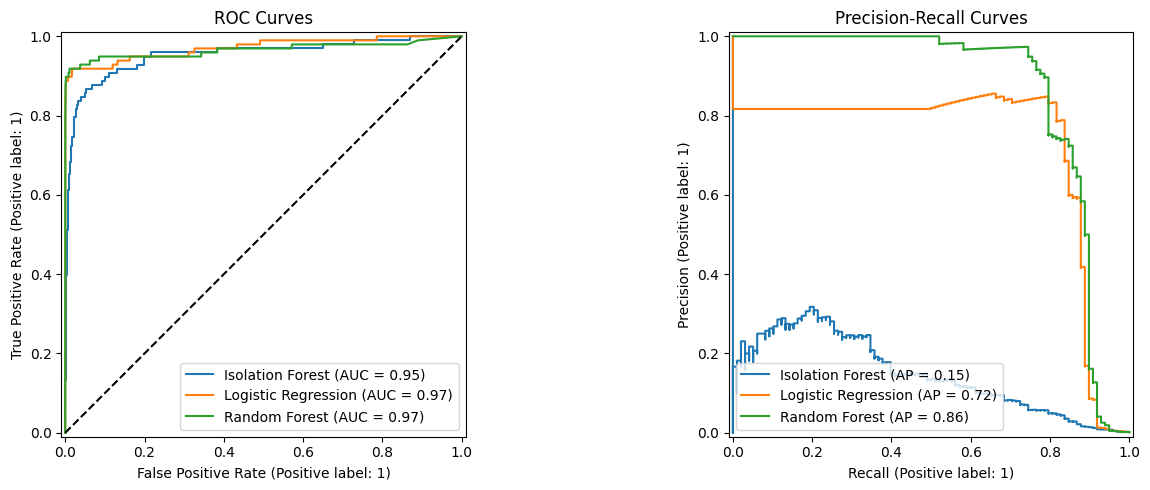

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC AUC (Isolation Forest uses decision_function scores)
iso_scores = -iso.decision_function(X_test)   # negate: higher = more anomalous

for name, scores in [('Isolation Forest', iso_scores), ('Logistic Regression', lr_probs), ('Random Forest', rf_probs)]:
    RocCurveDisplay.from_predictions(y_test, scores, name=name, ax=ax1)

ax1.set_title('ROC Curves')
ax1.plot([0,1],[0,1],'k--')

# Precision-Recall (more informative for imbalanced data)
for name, scores in [('Isolation Forest', iso_scores), ('Logistic Regression', lr_probs), ('Random Forest', rf_probs)]:
    PrecisionRecallDisplay.from_predictions(y_test, scores, name=name, ax=ax2)

ax2.set_title('Precision-Recall Curves')
plt.tight_layout()
plt.savefig('../assets/roc_pr_curves.png', dpi=150)

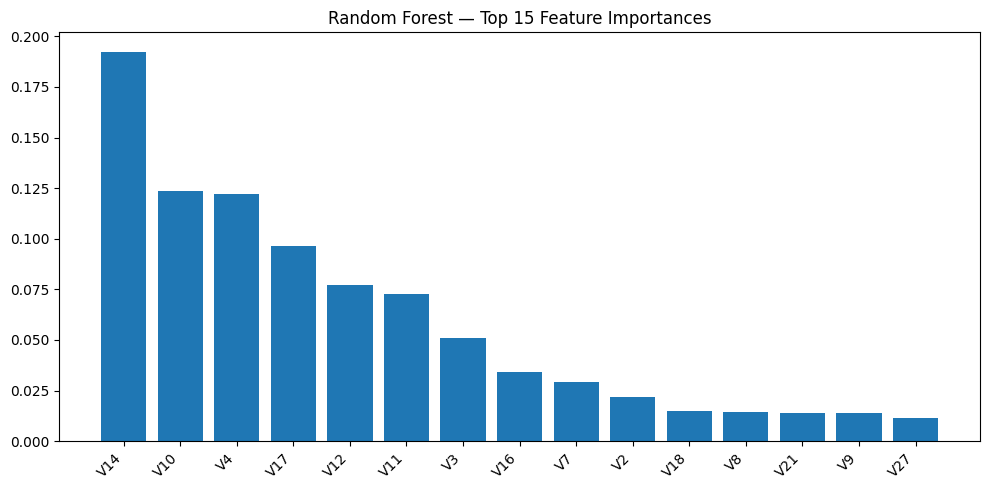

In [5]:
import numpy as np
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feat_names = X_test.columns
indices = np.argsort(importances)[::-1][:15]  # top 15

plt.figure(figsize=(10, 5))
plt.bar(range(15), importances[indices])
plt.xticks(range(15), feat_names[indices], rotation=45, ha='right')
plt.title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('../assets/feature_importance.png', dpi=150)